<a href="https://colab.research.google.com/github/tusharviradiya/ai-ml/blob/main/11_Practice/week3/Regression_Models_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ==============================================================================
# 1. IMPORTS & DATA LOADING
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

sns.set_theme(style="whitegrid")

# Load Kaggle Medical Insurance Dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
# ==============================================================================
# 2. PREPROCESSING & ENCODING
# ==============================================================================
# One-hot encode categorical variables ('sex', 'smoker', 'region')
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=["charges"], errors="ignore")
y = df_encoded["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

,Model,MAE ($),RMSE ($),R² Score
4,Gradient Boosting Regressor,2443.483262,4329.570011,0.879257
3,Random Forest Regressor,2543.975825,4567.775116,0.865606
2,Decision Tree Regressor,2697.765431,4592.764310,0.864131
0,Linear Regression,4181.194474,5796.284659,0.783593
1,Ridge Regression,4182.796597,5796.979691,0.783541


/tmp/ipykernel_2049/539654631.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=reg_results_df, x="Model", y="R² Score", palette="mako")


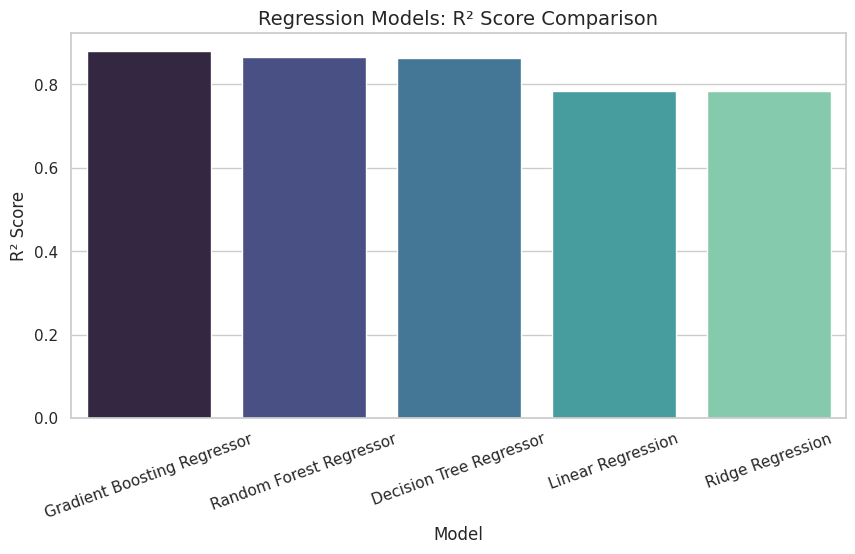

In [7]:
# ==============================================================================
# 3. REGRESSION MODELS BENCHMARKING
# ==============================================================================
regressors = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=4, random_state=42
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100, random_state=42
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=100, random_state=42
    ),
}

reg_results = []

for name, reg in regressors.items():
    reg.fit(X_train_scaled, y_train)
    y_pred = reg.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    reg_results.append(
        {"Model": name, "MAE ($)": mae, "RMSE ($)": rmse, "R² Score": r2}
    )

reg_results_df = pd.DataFrame(reg_results).sort_values(
    by="R² Score", ascending=False
)
display(reg_results_df)

# Visual Comparison of R²
plt.figure(figsize=(10, 5))
sns.barplot(data=reg_results_df, x="Model", y="R² Score", palette="mako")
plt.title("Regression Models: R² Score Comparison", fontsize=14)
plt.xticks(rotation=20)
plt.show()